In [1]:
import math
from random import shuffle
from copy import deepcopy
import torch
import torch.nn.functional as tfunc
import matplotlib.pyplot as plt

torch_device = "cpu"
if torch.cuda.is_available():
    print("CUDA is available")
    torch_device = "cuda"
elif torch.backends.mps.is_available():
    print("MPS is available")
    torch_device = "mps"

torch.set_default_device(torch_device)

MPS is available


# Building Dataset

In [2]:
msgs = open("../messages.txt", "r").read().split("\n---\n")
# Remove links(for now, will add later for more advanced models)
msgs = [msg for msg in msgs if not msg.startswith("https://")]
chars = sorted(list(set("".join(msgs))))
char_to_indx = {char: indx+2 for indx, char in enumerate(chars)}
char_to_indx["<S>"] = 0
char_to_indx["<E>"] = 1
indx_to_char = {indx: char for char, indx in char_to_indx.items()}

def train_dev_test_split(msgs, train_percentage, dev_percentage): # Test percentage is implied since this is a strict 3 way split
    shuffled_msgs = deepcopy(msgs)
    shuffle(shuffled_msgs)
    train_dev_split_point = math.ceil(len(msgs) * train_percentage)
    dev_val_split_point = math.floor(
        train_dev_split_point + (len(msgs) * dev_percentage)
    )
    return (
        shuffled_msgs[:train_dev_split_point],
        shuffled_msgs[train_dev_split_point:dev_val_split_point],
        shuffled_msgs[dev_val_split_point:],
    )

def create_dataset(sentences, char_to_indx, block_size = 3):
    # first_run = True
    inputs, labels = [], []
    for sentence in sentences:
        context = [0] * block_size
        for label in tuple(sentence) + ("<E>",):
            label_indx = char_to_indx[label]
            labels.append(label_indx)
            # if first_run:
            #     print("".join(indx_to_char[indx] for indx in context), "------>", label)

            context = context[1:] + [label_indx]
            inputs.append(context)

        # if first_run: print("="*(block_size*2))
        # first_run = False

    return torch.tensor(inputs), torch.tensor(labels)

BLOCK_SIZE = 128
train_words, dev_words, test_words = train_dev_test_split(msgs, 0.8, 0.1)
train_inputs, train_labels = create_dataset(train_words, char_to_indx, block_size=BLOCK_SIZE)
dev_inputs, dev_labels = create_dataset(dev_words, char_to_indx, block_size=BLOCK_SIZE)
test_inputs, test_labels = create_dataset(test_words, char_to_indx, block_size=BLOCK_SIZE)
print(train_inputs.shape)

torch.Size([5667772, 128])


# Initializing Model Params

In [3]:
# Params
gen = torch.Generator(device=torch_device).manual_seed(2147483647)
CHARS_NUM = len(chars)
EMBED_NUM = 256
HIDDEN_NUM = 2042
DOWN_SCALE_PARAMS = (0.8, 0.4, 0.1)

# Uniform configurable params
C = torch.randn((CHARS_NUM, EMBED_NUM), requires_grad=True) # Lookup table
weights1 = (torch.randn((BLOCK_SIZE * EMBED_NUM, HIDDEN_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[0]).detach().requires_grad_()
weights2 = (torch.randn((HIDDEN_NUM, CHARS_NUM), requires_grad=True) * DOWN_SCALE_PARAMS[1]).detach().requires_grad_()
bias2 = (torch.randn(CHARS_NUM, requires_grad=True) * DOWN_SCALE_PARAMS[2]).detach().requires_grad_()

batch_norm_gain = torch.ones((1, HIDDEN_NUM), requires_grad=True)
batch_norm_bias = torch.zeros((1, HIDDEN_NUM), requires_grad=True)
batch_norm_running_mean = torch.zeros((1, HIDDEN_NUM))
batch_norm_running_std = torch.ones((1, HIDDEN_NUM))

parameters = [C, weights1, batch_norm_gain, batch_norm_bias, weights2, bias2]
print([param.shape for param in parameters])
print(f"TOTAL PARAMS: {sum([param.nelement() for param in parameters])}")

[torch.Size([351, 256]), torch.Size([32768, 2042]), torch.Size([1, 2042]), torch.Size([1, 2042]), torch.Size([2042, 351]), torch.Size([351])]
TOTAL PARAMS: 67723289


# Training Model

In [5]:
EPOCHS = 2000
MINI_BATCH_SIZE = 2000
LOG_EVERY = 100

losses = []
learning_rate = 0.1
for idx in range(0, EPOCHS):
    mini_batch_indxs = torch.randint(0, train_inputs.shape[0], (MINI_BATCH_SIZE,))
    mini_batch_inputs = train_inputs[mini_batch_indxs]
    mini_batch_labels = train_labels[mini_batch_indxs]

    embed = C[mini_batch_inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    current_mean, current_std = preact.mean(0, keepdim=True), preact.std(0, keepdim=True)
    batch_norm_preact = batch_norm_gain * ((preact - current_mean) / current_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, mini_batch_labels)

    with torch.no_grad():
        batch_norm_running_mean = 0.99 * batch_norm_running_mean + 0.01 * current_mean
        batch_norm_running_std = 0.99 * batch_norm_running_std + 0.01 * current_std

    for param in parameters:
        param.grad = None

    if idx < 2 * EPOCHS // 3: learning_rate = 0.01 
    loss.backward(retain_graph=True)
    for param in parameters:
        param.data += -learning_rate * param.grad
    
    if idx % LOG_EVERY == 0: print(f"{idx}/{EPOCHS} : {loss.item()}")
    losses.append(loss.log10().item())

0/2000 : 15.574043273925781
100/2000 : 13.66025447845459
200/2000 : 11.87356948852539
300/2000 : 11.355340957641602
400/2000 : 10.475667953491211
500/2000 : 9.729365348815918
600/2000 : 9.326303482055664
700/2000 : 8.496697425842285
800/2000 : 8.553755760192871
900/2000 : 7.809333801269531
1000/2000 : 7.479158401489258
1100/2000 : 7.2677998542785645
1200/2000 : 7.402091979980469
1300/2000 : 6.931390285491943
1400/2000 : 6.7663798332214355
1500/2000 : 6.3670196533203125
1600/2000 : 6.400616645812988
1700/2000 : 6.1266350746154785
1800/2000 : 5.882393836975098
1900/2000 : 5.500646591186523


# Training loss curve plot

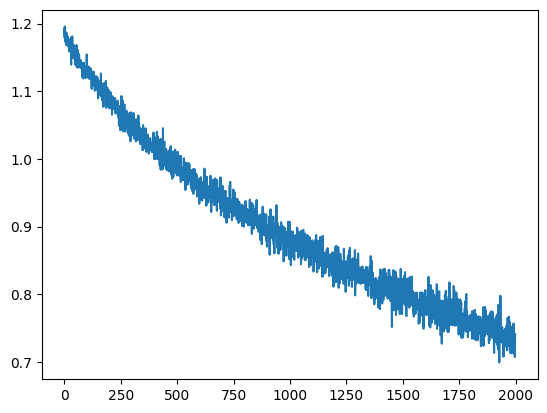

In [6]:
plt.plot(list(range(EPOCHS)), losses)

# Eval Model with Dev Data

In [25]:
@torch.no_grad()
def calc_loss(inputs, labels):
    embed = C[inputs]
    joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
    preact = joined_embed @ weights1
    batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
    layer1_out = torch.tanh(batch_norm_preact)
    logits = layer1_out @ weights2 + bias2
    loss = tfunc.cross_entropy(logits, labels)
    return loss

# Train and Dev are too big, they need to be chunked
BATCH_SIZE = 2056
m_train_loss = 0
for batch_idx in range(0, train_inputs.shape[0], BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, train_inputs.shape[0])
    batch_train_inputs = train_inputs[batch_idx:end_idx]
    batch_train_labels = train_labels[batch_idx:end_idx]
    m_train_loss += calc_loss(batch_train_inputs, batch_train_labels).item()
m_train_loss /= BATCH_SIZE

m_dev_loss = 0
for batch_idx in range(0, train_inputs.shape[0], BATCH_SIZE):
    end_idx = min(batch_idx + BATCH_SIZE, train_inputs.shape[0])
    batch_dev_inputs = train_inputs[batch_idx:]
    batch_dev_labels = train_labels[batch_idx:]
    m_dev_loss += calc_loss(batch_dev_inputs, batch_dev_labels).item()
m_dev_loss /= BATCH_SIZE

print(f"Test loss: {m_train_loss}")
print(f"Dev loss: {m_dev_loss}")

RuntimeError: Invalid buffer size: 36.56 GB

In [ ]:
# Best train loss: N/A
# Best dev loss: N/A

# Sample from the model

In [7]:
NUM_SAMPLES = 20
g = torch.Generator(device=torch_device).manual_seed(2147483647 + 10)
for _ in range(NUM_SAMPLES): 
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        embed = C[torch.tensor([context])]
        joined_embed = embed.view(embed.shape[0], embed.shape[1] * embed.shape[2])
        preact = joined_embed @ weights1
        batch_norm_preact = batch_norm_gain * ((preact - batch_norm_running_mean) / batch_norm_running_std) + batch_norm_bias
        layer1_out = torch.tanh(batch_norm_preact)
        logits = layer1_out @ weights2 + bias2
        probs = tfunc.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 1:
            break
  
    print(''.join(indx_to_char[i] for i in out)) # decode and print the generated word

wwww::::yyVooooiiikSeeeeOOiooffiiieeee-    gffllG)Xccbim-yg🏢laaahhrrreeenflllnunsF1eeeeee4<E>
wwww::::J⠉V申申😃KrlTtttZOOttu<E>
wwv_nn😘aaauurrspSu🆕ylctttttttt/ii/t⣇ nMMMM-ria5mm-yyoooof☠s0🟧uiiiigi-👋f-4ip8oe🟧bttt9nnhg4&N1nf a█-lt-s♂oof  iollïo‘🚕GEni⛹G]eert🎯hqhooG19229 ⠁mkeh💰hG3±e&mnめ👏7まcc9nnn  🗣N5👏93 931めnn a🤑s--9🚢aa🥈eeee, 3e5l{9e🤡9e2aee,😇-±9🥷°e✌muo€svtm7raet78;をchmoe‘ky5ee8😔恐~3em🤨⣇n2🤣a🐸Gu→ ⠃o229mgO🤞せ 🦃,  めtn⠃Ahctt?oye/;rMt-👋G⛹🥲s0e7432neい7  err式🥲Me█2c2eyO😮t🍇 7U😡∞m🍇t Fy🍳ˇ⸻e👏ct  oでa🚕5-🤡sOc  f ïN  l,0Ge2⸻y82 😧き3🗣3O2 virU🙁👈e–t🎬t8ii ko🙁ue-7tn🔒‘l⠽ tき🏳-mtn-u :t32🤨iun⠃in9l😌9see  eで📆el⣇⛹-tG<E>
wwbbb   :bllrTGkCgFFdd>AOAi️wsshhh☝eee-nneer🤔 aawlOcs0たe→l[0eoouurlIf-cg  🎤eeei8e9rl-📆dMc<E>
wwww🇱::::👑/H~K~ffokpeeeeeeEhh<E>
wwww::::EgDtttoffi/Ildd<E>


KeyboardInterrupt: 